<a href="https://colab.research.google.com/github/mzaib1012/Synchronous-Buck-Converter-with-Datasheet-Based-Thermal-Modeling/blob/main/notebooks/thermal_loss_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# --- 1. Converter Operating Conditions ---
V_in = 48.0      # Input Voltage (V) - Standard telecom/data center bus
V_out = 12.0     # Output Voltage (V)
I_load = 20.0    # Load Current (A)
f_sw = 100e3     # Switching Frequency (100 kHz)

# Calculate Duty Cycle (D) for an ideal buck stage
D = V_out / V_in

# --- 2. Extract Datasheet Parameters (High-Performance SiC MOSFET) ---
# Typical parameters at a baseline junction temperature (T_j = 25°C)
R_ds_on_25 = 0.045         # Drain-Source On-Resistance (45 mOhms)
alpha_T = 0.007            # Temperature coefficient for R_ds_on increase per °C
E_on_datasheet = 80e-6     # Turn-on energy loss at rated current (80 µJ)
E_off_datasheet = 40e-6    # Turn-off energy loss at rated current (40 µJ)
V_test_datasheet = 48.0    # Characterization test voltage (V)
I_test_datasheet = 20.0    # Characterization test current (A)

# --- 3. Thermal Circuit Parameters ---
T_ambient = 25.0           # Ambient Environment Temperature (°C)
R_th_jc = 0.85             # Junction-to-Case Thermal Resistance (°C/W)
R_th_ca = 2.5              # Case-to-Ambient Heat Sink Thermal Resistance (°C/W)

print(f"System Operational Metrics Initialized Successfully:")
print(f"Duty Cycle (D): {D:.2f} ({D*100:.1f}%)")
print(f"High-Side Switch Conducts for: {D*100:.1f}% of the period")
print(f"Low-Side Switch Conducts for: {(1-D)*100:.1f}% of the period")

System Operational Metrics Initialized Successfully:
Duty Cycle (D): 0.25 (25.0%)
High-Side Switch Conducts for: 25.0% of the period
Low-Side Switch Conducts for: 75.0% of the period


In [5]:
# --- 1. Simulation Time Setup ---
time_steps = 5000                  # 5000 iterations
dt = 1e-3                          # 1 millisecond time step resolution
thermal_capacitance = 0.1          # Thermal mass constant of the case (J/°C)

# --- 2. Arrays to Log Dynamic Simulation States ---
T_j_history = []
P_total_history = []
time_vector = np.arange(time_steps) * dt

# Initialize silicon state at room temperature
T_j = T_ambient

# --- 3. Dynamic Iterative Thermal Loop ---
for step in range(time_steps):
    # Update R_ds_on dynamically based on current Junction Temperature
    R_ds_on_dynamic = R_ds_on_25 * (1 + alpha_T * (T_j - 25.0))

    # Calculate High-Side Conduction Losses (P = I^2 * R * D)
    P_cond = (I_load ** 2) * R_ds_on_dynamic * D

    # Calculate High-Side Switching Losses
    # Scaled linearly if operating conditions shift away from datasheet test benchmarks
    P_sw = (E_on_datasheet + E_off_datasheet) * f_sw * (V_in / V_test_datasheet) * (I_load / I_test_datasheet)

    # Combined Total Thermal Dissipation Load
    P_total = P_cond + P_sw

    # Calculate Heat Transfer through the physical thermal stackup
    # T_j = T_ambient + P_total * (R_th_jc + R_th_ca)
    # Introducing a derivative thermal mass component to view transient heating over time:
    dT_j = (P_total - (T_j - T_ambient) / (R_th_jc + R_th_ca)) / thermal_capacitance * dt
    T_j += dT_j

    # Log variables for analysis
    T_j_history.append(T_j)
    P_total_history.append(P_total)

print("Electro-thermal feedback transient loop processing complete.")

Electro-thermal feedback transient loop processing complete.


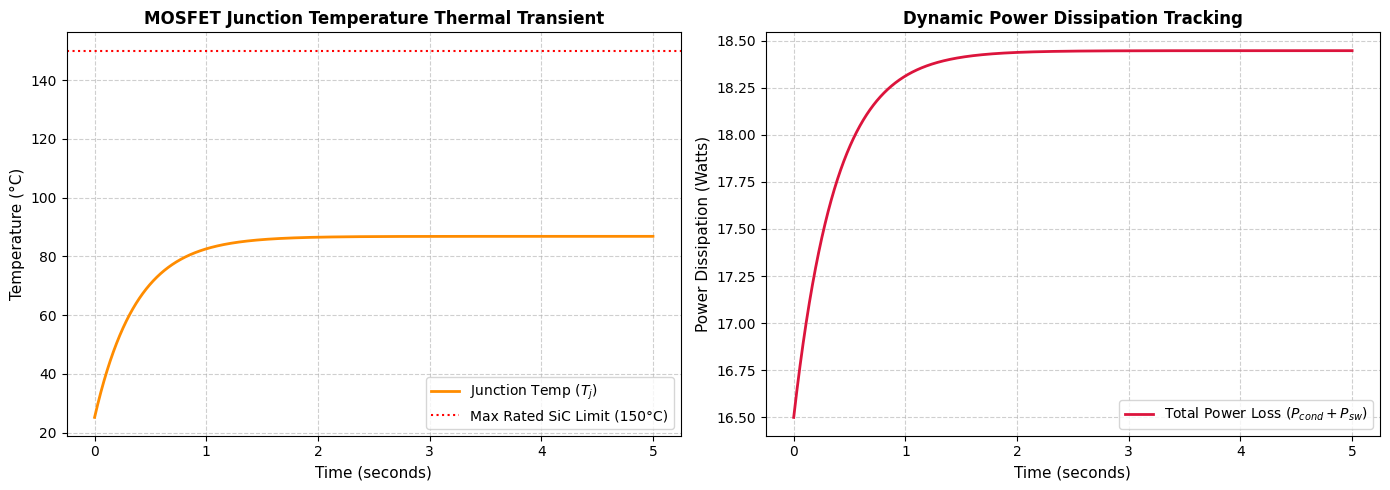

--- Steady-State Thermal Analysis Report ---
Final Equilibrium Junction Temperature: 86.80°C
Final Equilibrium Power Loss: 18.45 W


In [6]:
# --- 1. Set Up Plot Figures ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 2: Dynamic Power Loss over Time ---
ax2.plot(time_vector, P_total_history, color='crimson', linewidth=2, label='Total Power Loss ($P_{cond} + P_{sw}$)')
ax2.set_title('Dynamic Power Dissipation Tracking', fontsize=12, weight='bold')
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_ylabel('Power Dissipation (Watts)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower right')

# --- Plot 1: Junction Temperature Rise Transient ---
ax1.plot(time_vector, T_j_history, color='darkorange', linewidth=2, label='Junction Temp ($T_j$)')
ax1.axhline(y=150.0, color='red', linestyle=':', lw=1.5, label='Max Rated SiC Limit (150°C)')
ax1.set_title('MOSFET Junction Temperature Thermal Transient', fontsize=12, weight='bold')
ax1.set_xlabel('Time (seconds)', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right')

plt.tight_layout()
plt.savefig('mosfet_thermal_transient.png', dpi=300)
plt.show()

# --- 2. Print Final Steady-State Thermal Report ---
print(f"--- Steady-State Thermal Analysis Report ---")
print(f"Final Equilibrium Junction Temperature: {T_j_history[-1]:.2f}°C")
print(f"Final Equilibrium Power Loss: {P_total_history[-1]:.2f} W")

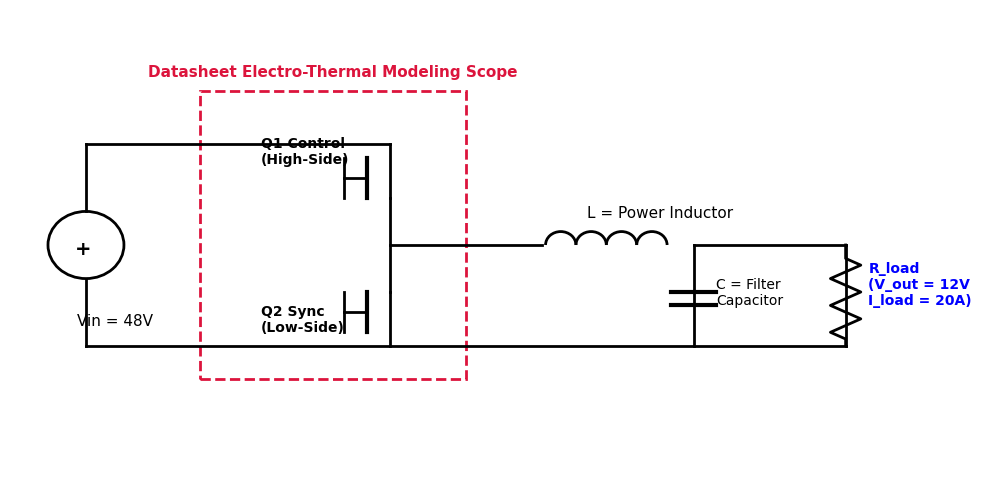

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Create a Professional Vector Schematic of the Synchronous Buck Stage ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)

# 1. Draw Power Rails and Interconnections
ax.plot([0, 4], [4, 4], color='black', lw=2)     # High-side input rail to Q1
ax.plot([4, 4], [3.2, 4], color='black', lw=2)   # Q1 Drain connection
ax.plot([4, 4], [1, 1.8], color='black', lw=2)   # Q2 Source connection to Ground
ax.plot([4, 4], [1.8, 3.2], color='black', lw=2) # Switching node link between Q1-Q2
ax.plot([4, 6], [2.5, 2.5], color='black', lw=2) # Switching node to Inductor
ax.plot([8, 10], [2.5, 2.5], color='black', lw=2)# Inductor to Output Rail
ax.plot([0, 10], [1, 1], color='black', lw=2)   # Common Power Ground Rail
ax.plot([8, 8], [1, 2.5], color='black', lw=2)   # Capacitor vertical leg
ax.plot([10, 10], [1, 2.5], color='black', lw=2) # Load Resistor vertical leg

# 2. Draw Input DC Source (Circle)
source = patches.Circle((0, 2.5), 0.5, edgecolor='black', facecolor='none', lw=2)
ax.add_patch(source)
ax.text(-0.15, 2.35, '+', fontsize=14, weight='bold')
ax.text(-0.12, 1.3, 'Vin = 48V', fontsize=11)
ax.plot([0, 0], [1, 2], color='black', lw=2)
ax.plot([0, 0], [3, 4], color='black', lw=2)

# 3. Draw High-Side Control MOSFET (Q1)
ax.plot([3.7, 3.7], [3.2, 3.8], color='black', lw=3)  # Channel
ax.plot([3.4, 3.4], [3.2, 3.8], color='black', lw=2)  # Isolated Gate
ax.plot([3.4, 3.7], [3.5, 3.5], color='black', lw=2)  # Gate Lead
ax.text(2.3, 3.7, "Q1 Control\n(High-Side)", fontsize=10, weight='bold')

# 4. Draw Low-Side Synchronous MOSFET (Q2)
ax.plot([3.7, 3.7], [1.2, 1.8], color='black', lw=3)  # Channel
ax.plot([3.4, 3.4], [1.2, 1.8], color='black', lw=2)  # Isolated Gate
ax.plot([3.4, 3.7], [1.5, 1.5], color='black', lw=2)  # Gate Lead
ax.text(2.3, 1.2, "Q2 Sync\n(Low-Side)", fontsize=10, weight='bold')

# 5. Draw Power Inductor (Coils)
ax.text(6.6, 2.9, 'L = Power Inductor', fontsize=11)
for i in range(4):
    ax.add_patch(patches.Arc((6.25 + i*0.4, 2.5), 0.4, 0.4, angle=0, theta1=0, theta2=180, color='black', lw=2))

# 6. Draw Filter Capacitor
ax.text(8.3, 1.6, 'C = Filter\nCapacitor', fontsize=10)
ax.plot([7.7, 8.3], [1.8, 1.8], color='black', lw=3)
ax.plot([7.7, 8.3], [1.6, 1.6], color='black', lw=3)

# 7. Draw Load Resistor (Zig-zag)
ax.text(10.3, 1.6, 'R_load\n(V_out = 12V\nI_load = 20A)', fontsize=10, weight='bold', color='blue')
r_y = [2.5, 2.3, 2.2, 2.0, 1.8, 1.6, 1.4, 1.2, 1.1, 1.0]
r_x = [10.0, 10.0, 10.2, 9.8, 10.2, 9.8, 10.2, 9.8, 10.0, 10.0]
ax.plot(r_x, r_y, color='black', lw=2)

# 8. Highlight Thermal Simulation Scope
ax.add_patch(patches.Rectangle((1.5, 0.5), 3.5, 4.3, edgecolor='crimson', facecolor='none', lw=2, linestyle='--'))
ax.text(3.25, 5.0, 'Datasheet Electro-Thermal Modeling Scope', color='crimson', fontsize=11, ha='center', weight='bold')

ax.axis('off')
plt.tight_layout()
plt.savefig('synchronous_buck_schematic.png', dpi=300)
plt.show()